In [4]:
import pandas as pd
import os

# 기준 월 리스트
months = ['201807', '201808', '201809', '201810', '201811', '201812']
member_path_tpl = "C:/Users/HR/Desktop/workspace/파이널프로젝트/open/train/1.회원정보/{ym}_train_회원정보.parquet"
bill_path_tpl = "C:/Users/HR/Desktop/workspace/파이널프로젝트/open/train/4.청구입금정보/{ym}_train_청구정보.parquet"

member_list = []
bill_list = []

for ym in months:
    member_df = pd.read_parquet(member_path_tpl.format(ym=ym))
    bill_df = pd.read_parquet(bill_path_tpl.format(ym=ym))

    member_df['기준년월'] = ym
    bill_df['기준년월'] = ym

    member_list.append(member_df)
    bill_list.append(bill_df)

# 병합
member_all = pd.concat(member_list, ignore_index=True)
bill_all = pd.concat(bill_list, ignore_index=True)

# ID 기준으로 병합 (Segment 포함)
merged = pd.merge(member_all[['ID', 'Segment']], bill_all, on='ID', how='inner')


C:\Users\HR\AppData\Local\Temp\ipykernel_23676\2045458462.py:29: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=merged, x='Segment', y=col, ci=None, palette=color_map)
C:\Users\HR\AppData\Local\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


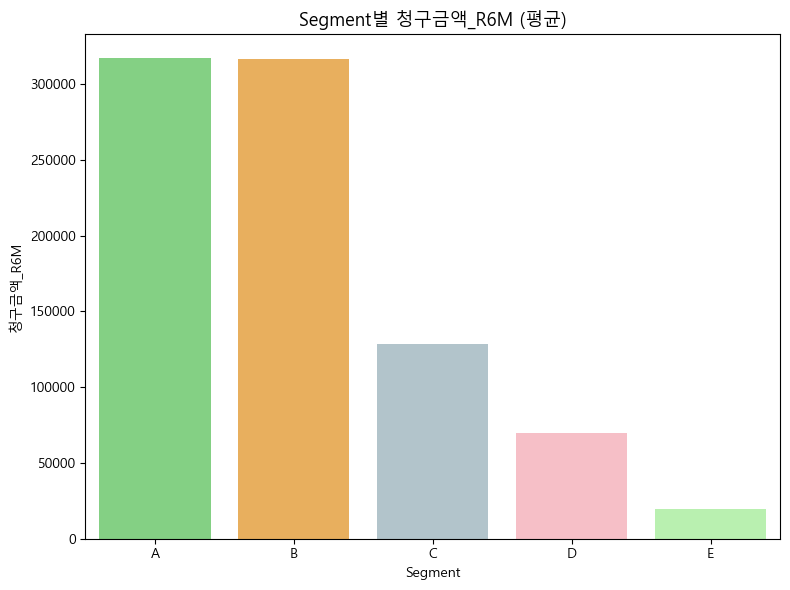

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import pandas as pd

# ✅ 폰트 설정
font_path = "C:/Windows/Fonts/malgun.ttf"
font_prop = fm.FontProperties(fname=font_path)

# ✅ Segment 순서 고정
segment_order = ['A', 'B', 'C', 'D', 'E']
merged['Segment'] = pd.Categorical(merged['Segment'], categories=segment_order, ordered=True)

# ✅ 보고 싶은 컬럼 지정
target_columns = ['청구금액_R6M']  # 여기에 원하는 컬럼 추가 가능

# ✅ 컬러 맵 정의
color_map = {
    'A': '#77DD77',
    'B': '#FFB347',
    'C': '#AEC6CF',
    'D': '#FFB6C1',
    'E': '#B2FBA5',
}

# ✅ 그래프 출력
for col in target_columns:
    plt.figure(figsize=(8, 6))
    sns.barplot(data=merged, x='Segment', y=col, ci=None, palette=color_map)
    plt.title(f"Segment별 {col} (평균)", fontproperties=font_prop, fontsize=13)
    plt.xlabel("Segment", fontproperties=font_prop)
    plt.ylabel(col, fontproperties=font_prop)
    plt.xticks(fontproperties=font_prop)
    plt.yticks(fontproperties=font_prop)
    plt.tight_layout()
    plt.show()



C:\Users\HR\AppData\Local\Temp\ipykernel_13260\4037138816.py:50: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\HR\AppData\Local\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


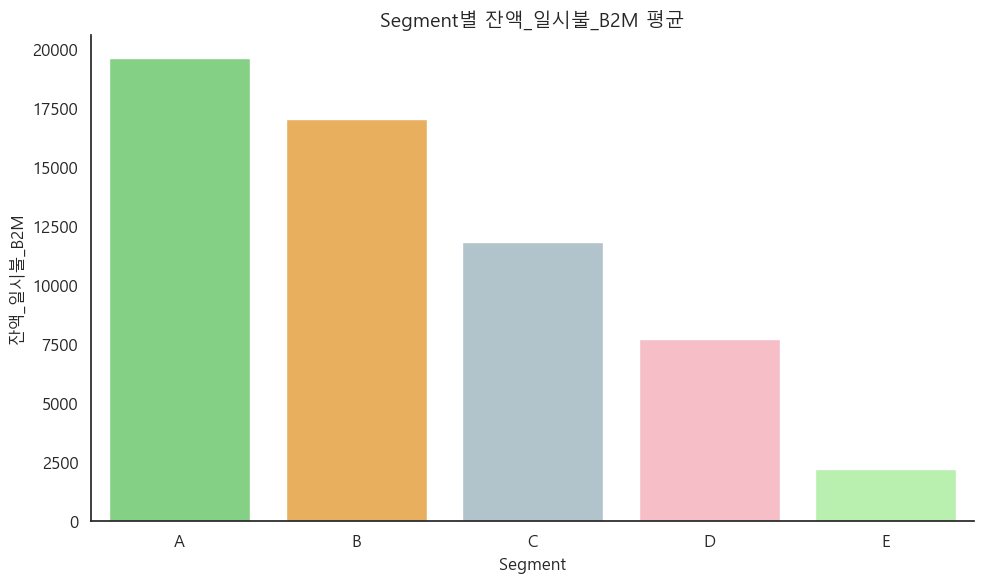

In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ✅ 한글 폰트 설정
font_path = "C:/Windows/Fonts/malgun.ttf"
font_prop = fm.FontProperties(fname=font_path)

# ✅ 기준 월 리스트 및 파일 경로 템플릿
months = ['201807', '201808', '201809', '201810', '201811', '201812']
member_path_tpl = "C:/Users/HR/Desktop/workspace/파이널프로젝트/open/train/1.회원정보/{ym}_train_회원정보.parquet"
bill_path_tpl = "C:/Users/HR/Desktop/workspace/파이널프로젝트/open/train/5.잔액정보/{ym}_train_잔액정보.parquet"

# ✅ 병합용 리스트
member_list = []
bill_list = []

# ✅ 월별 파일 불러오기 및 컬럼 추출
for ym in months:
    member_df = pd.read_parquet(member_path_tpl.format(ym=ym))[['ID', 'Segment']]
    bill_df = pd.read_parquet(bill_path_tpl.format(ym=ym))[['ID', '잔액_일시불_B2M']]

    member_df['기준년월'] = ym
    bill_df['기준년월'] = ym

    member_list.append(member_df)
    bill_list.append(bill_df)

# ✅ 병합
member_all = pd.concat(member_list, ignore_index=True)
bill_all = pd.concat(bill_list, ignore_index=True)
merged = pd.merge(member_all, bill_all, on='ID', how='inner')

# ✅ Segment 순서 고정
segment_order = ['A', 'B', 'C', 'D', 'E']
merged['Segment'] = pd.Categorical(merged['Segment'], categories=segment_order, ordered=True)

# ✅ 컬러 맵 정의
color_map = {
    'A': '#77DD77',
    'B': '#FFB347',
    'C': '#AEC6CF',
    'D': '#FFB6C1',
    'E': '#B2FBA5',
}

# ✅ 시각화 (색상 지정)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=merged,
    x='Segment',
    y='잔액_일시불_B2M',
    ci=None,
    order=segment_order,
    palette=color_map
)
plt.title("Segment별 잔액_일시불_B2M 평균", fontproperties=font_prop, fontsize=14)
plt.xlabel("Segment", fontproperties=font_prop)
plt.ylabel("잔액_일시불_B2M", fontproperties=font_prop)
plt.xticks(fontproperties=font_prop)
plt.yticks(fontproperties=font_prop)
sns.despine()
plt.tight_layout()
plt.show()



C:\Users\HR\AppData\Local\Temp\ipykernel_13260\317339368.py:55: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=merged, x='Segment', y=col, ci=None)
C:\Users\HR\AppData\Local\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


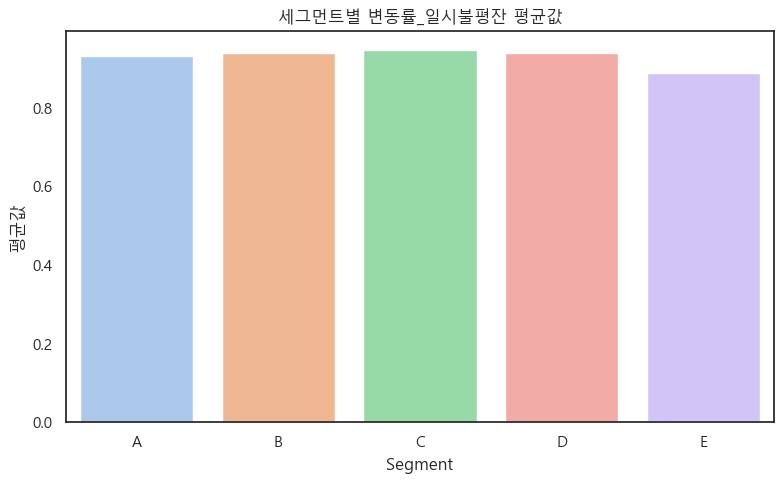

C:\Users\HR\AppData\Local\Temp\ipykernel_13260\317339368.py:55: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=merged, x='Segment', y=col, ci=None)
C:\Users\HR\AppData\Local\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


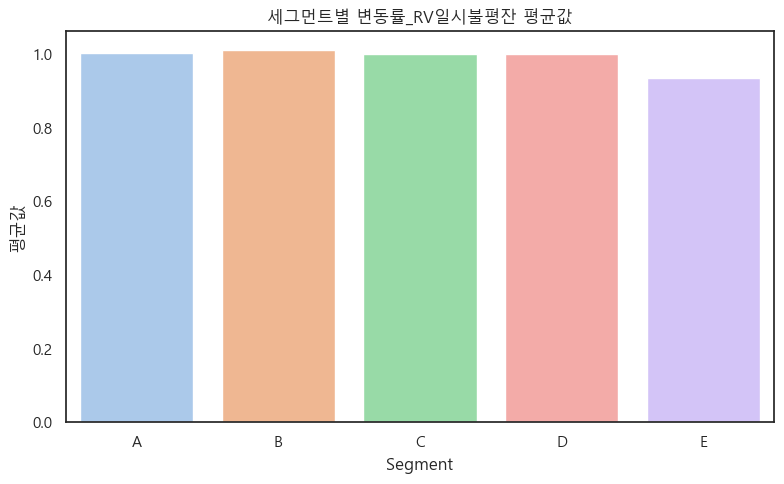

C:\Users\HR\AppData\Local\Temp\ipykernel_13260\317339368.py:55: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=merged, x='Segment', y=col, ci=None)
C:\Users\HR\AppData\Local\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


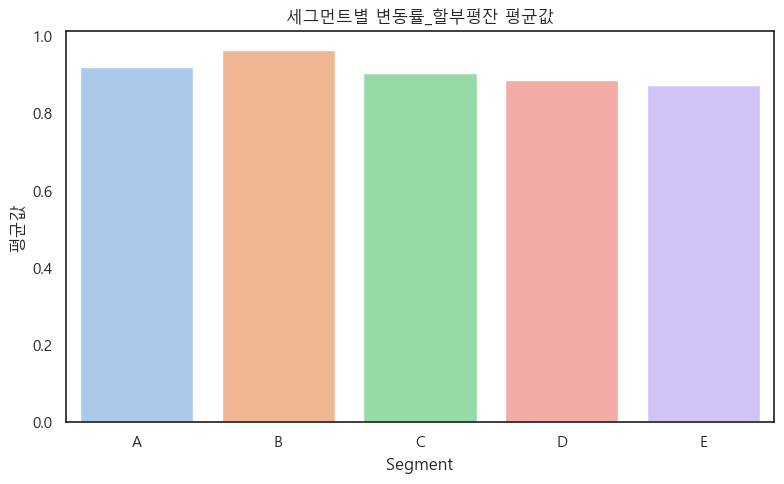

C:\Users\HR\AppData\Local\Temp\ipykernel_13260\317339368.py:55: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=merged, x='Segment', y=col, ci=None)
C:\Users\HR\AppData\Local\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


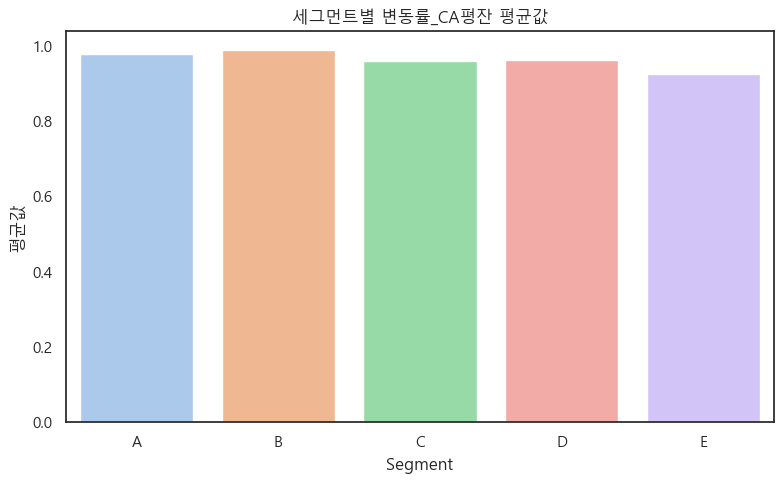

C:\Users\HR\AppData\Local\Temp\ipykernel_13260\317339368.py:55: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=merged, x='Segment', y=col, ci=None)
C:\Users\HR\AppData\Local\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


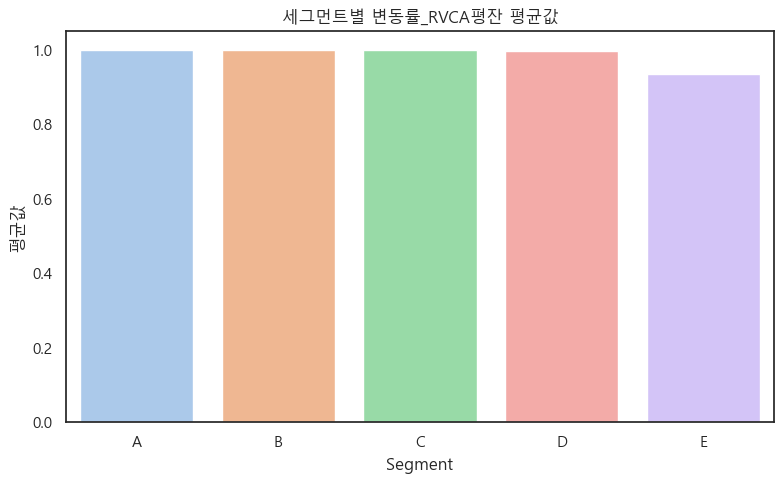

C:\Users\HR\AppData\Local\Temp\ipykernel_13260\317339368.py:55: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=merged, x='Segment', y=col, ci=None)
C:\Users\HR\AppData\Local\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


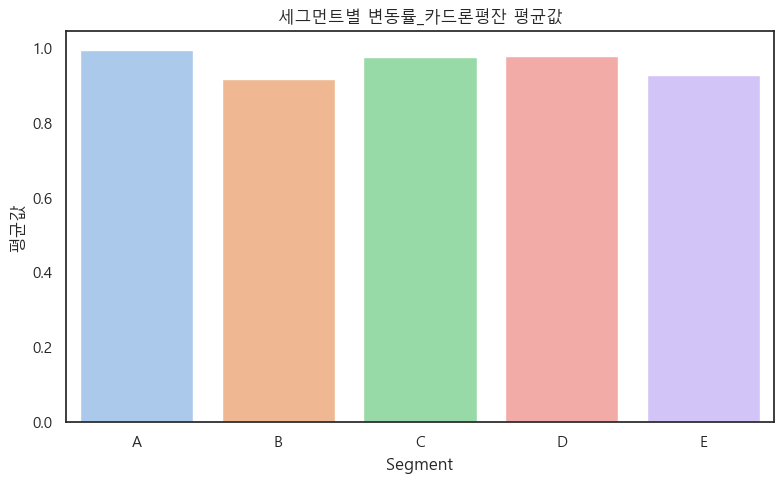

C:\Users\HR\AppData\Local\Temp\ipykernel_13260\317339368.py:55: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=merged, x='Segment', y=col, ci=None)
C:\Users\HR\AppData\Local\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


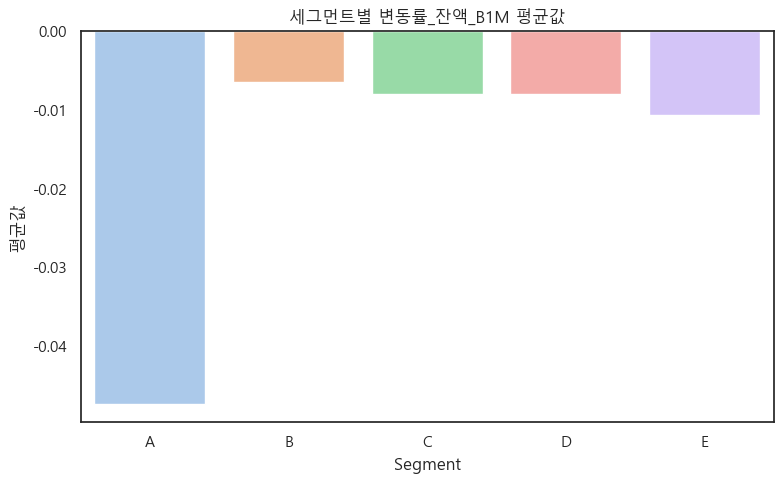

C:\Users\HR\AppData\Local\Temp\ipykernel_13260\317339368.py:55: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=merged, x='Segment', y=col, ci=None)
C:\Users\HR\AppData\Local\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


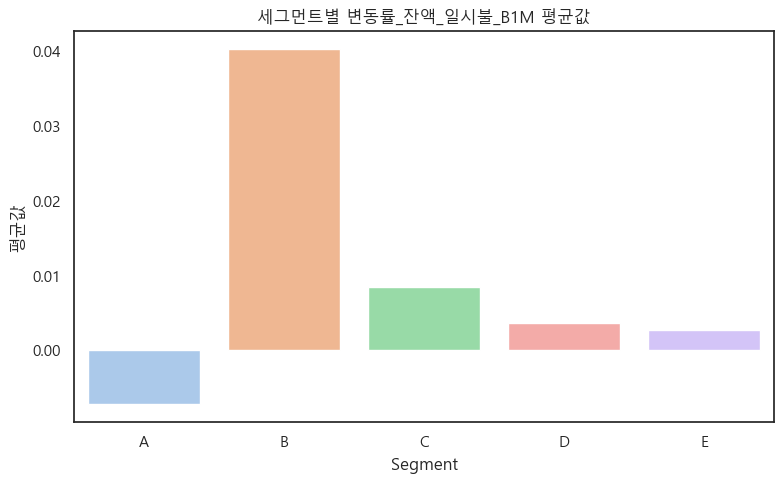

C:\Users\HR\AppData\Local\Temp\ipykernel_13260\317339368.py:55: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=merged, x='Segment', y=col, ci=None)
C:\Users\HR\AppData\Local\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


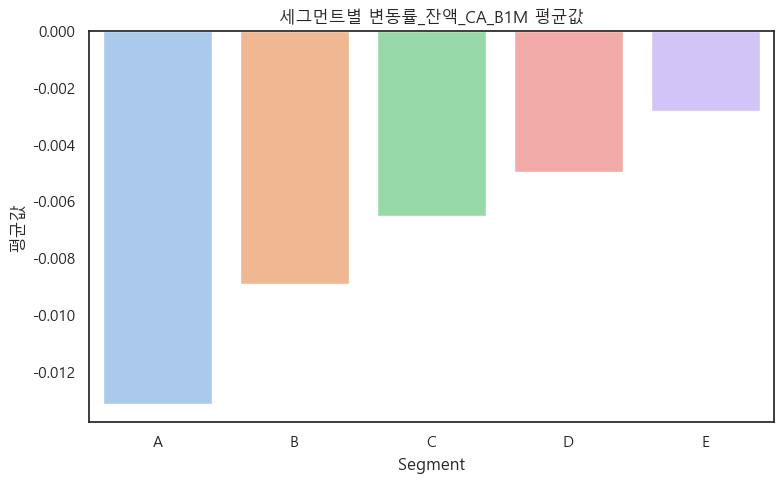

In [47]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import matplotlib as mpl

# ✅ 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

# ✅ 기준 월 리스트
months = ['201807', '201808', '201809', '201810', '201811', '201812']

# ✅ 파일 경로
member_path_tpl = "C:/Users/HR/Desktop/workspace/파이널프로젝트/open/train/1.회원정보/{ym}_train_회원정보.parquet"
perf_path_tpl = "C:/Users/HR/Desktop/workspace/파이널프로젝트/open/train/8.성과정보/{ym}_train_성과정보.parquet"

# ✅ 로딩용 리스트
member_list = []
perf_list = []

# ✅ 월별 데이터 로드 및 기준월 추가
for ym in months:
    member_df = pd.read_parquet(member_path_tpl.format(ym=ym))[['ID', 'Segment']]
    perf_df = pd.read_parquet(perf_path_tpl.format(ym=ym))
    perf_df['기준년월'] = ym
    member_df['기준년월'] = ym
    member_list.append(member_df)
    perf_list.append(perf_df)

# ✅ 전체 데이터 병합
member_all = pd.concat(member_list, ignore_index=True)
perf_all = pd.concat(perf_list, ignore_index=True)

# ✅ 사용할 컬럼 (존재하는 컬럼만 추출)
target_cols = [
    '변동률_일시불평잔', '변동률_RV일시불평잔', '변동률_할부평잔',
    '변동률_CA평잔', '변동률_RVCA평잔', '변동률_카드론평잔',
    '변동률_잔액_B1M', '변동률_잔액_일시불_B1M', '변동률_잔액_CA_B1M'
]
available_cols = [col for col in target_cols if col in perf_all.columns]

# ✅ 필요한 컬럼만 선택
perf_selected = perf_all[['ID', '기준년월'] + available_cols]
merged = pd.merge(member_all, perf_selected, on=['ID', '기준년월'], how='inner')

# ✅ Segment를 Categorical로 (순서 지정)
segment_order = ['A', 'B', 'C', 'D', 'E']
merged['Segment'] = pd.Categorical(merged['Segment'], categories=segment_order, ordered=True)

# ✅ 바플롯 (컬럼별, 세그먼트별 평균값)
for col in available_cols:
    plt.figure(figsize=(8, 5))
    sns.barplot(data=merged, x='Segment', y=col, ci=None)
    plt.title(f"세그먼트별 {col} 평균값")
    plt.xlabel("Segment")
    plt.ylabel("평균값")
    plt.tight_layout()
    plt.show()


C:\Users\HR\AppData\Local\Temp\ipykernel_13260\570149590.py:53: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\HR\AppData\Local\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


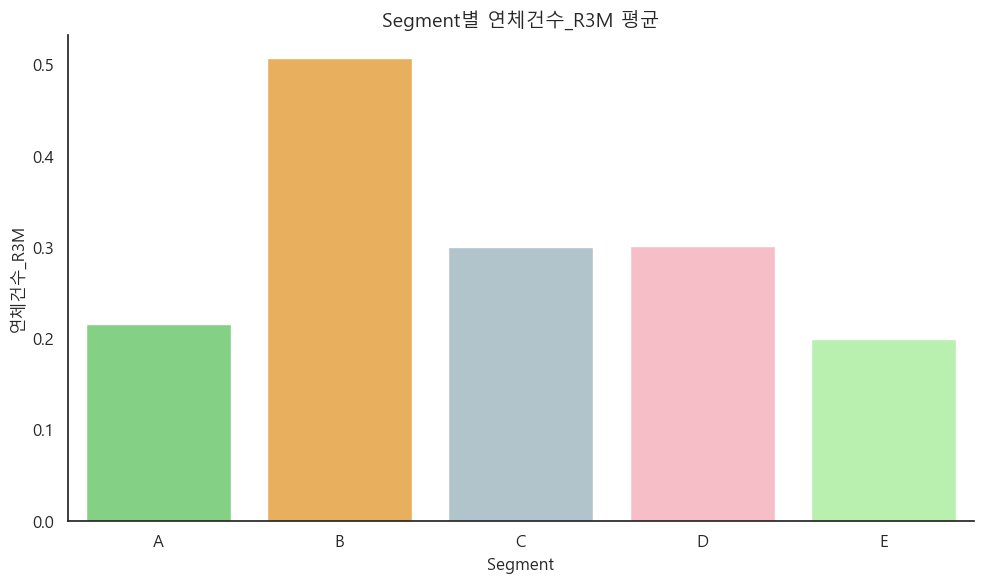

C:\Users\HR\AppData\Local\Temp\ipykernel_13260\570149590.py:53: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\HR\AppData\Local\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


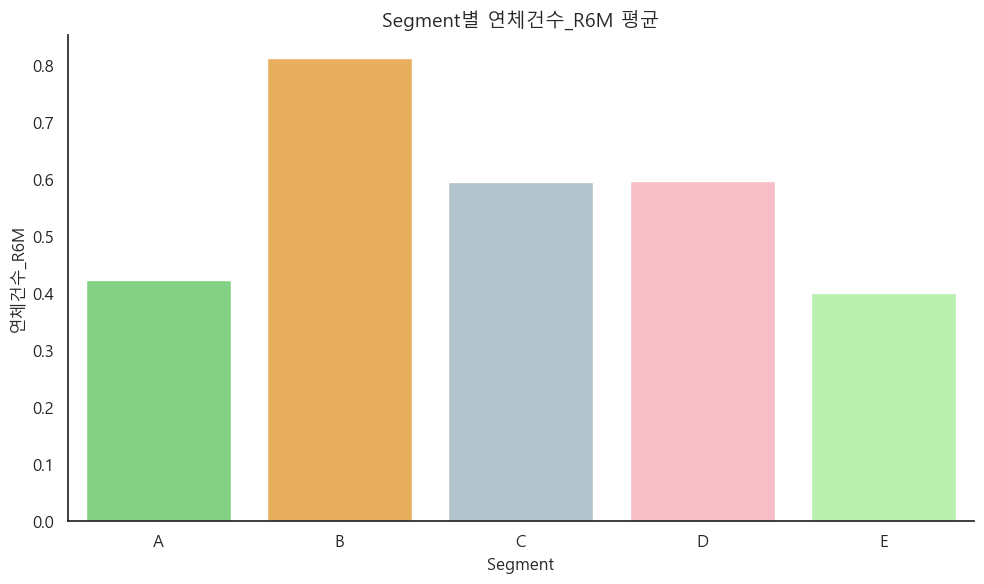

In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ✅ 한글 폰트 설정
font_path = "C:/Windows/Fonts/malgun.ttf"
font_prop = fm.FontProperties(fname=font_path)

# ✅ 기준 월 리스트 및 파일 경로 템플릿
months = ['201807', '201808', '201809', '201810', '201811', '201812']
member_path_tpl = "C:/Users/HR/Desktop/workspace/파이널프로젝트/open/train/1.회원정보/{ym}_train_회원정보.parquet"
perf_path_tpl = "C:/Users/HR/Desktop/workspace/파이널프로젝트/open/train/4.청구입금정보/{ym}_train_청구정보.parquet"

# ✅ 데이터 불러오기
member_list = []
perf_list = []

for ym in months:
    member_df = pd.read_parquet(member_path_tpl.format(ym=ym))[['ID', 'Segment']]
    perf_df = pd.read_parquet(perf_path_tpl.format(ym=ym))

    member_df['기준년월'] = ym
    perf_df['기준년월'] = ym

    member_list.append(member_df)
    perf_list.append(perf_df)

# ✅ 데이터 병합
member_all = pd.concat(member_list, ignore_index=True)
perf_all = pd.concat(perf_list, ignore_index=True)

# ✅ 사용할 컬럼
target_cols = ['연체건수_R3M', '연체건수_R6M']
available_cols = [col for col in target_cols if col in perf_all.columns]
perf_selected = perf_all[['ID', '기준년월'] + available_cols]

merged = pd.merge(member_all, perf_selected, on=['ID', '기준년월'], how='inner')
merged['Segment'] = pd.Categorical(merged['Segment'], categories=['A', 'B', 'C', 'D', 'E'], ordered=True)

# ✅ 컬러 맵 정의
color_map = {
    'A': '#77DD77',
    'B': '#FFB347',
    'C': '#AEC6CF',
    'D': '#FFB6C1',
    'E': '#B2FBA5',
}

# ✅ 시각화 - 컬럼별 바플롯
for col in available_cols:
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=merged,
        x='Segment',
        y=col,
        ci=None,
        order=['A', 'B', 'C', 'D', 'E'],
        palette=color_map
    )
    plt.title(f"Segment별 {col} 평균", fontproperties=font_prop, fontsize=14)
    plt.xlabel("Segment", fontproperties=font_prop)
    plt.ylabel(col, fontproperties=font_prop)
    plt.xticks(fontproperties=font_prop)
    plt.yticks(fontproperties=font_prop)
    sns.despine()
    plt.tight_layout()
    plt.show()



C:\Users\HR\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\HR\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(
C:\Users\HR\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\HR\AppData\Local\anaconda3\Lib\site-package

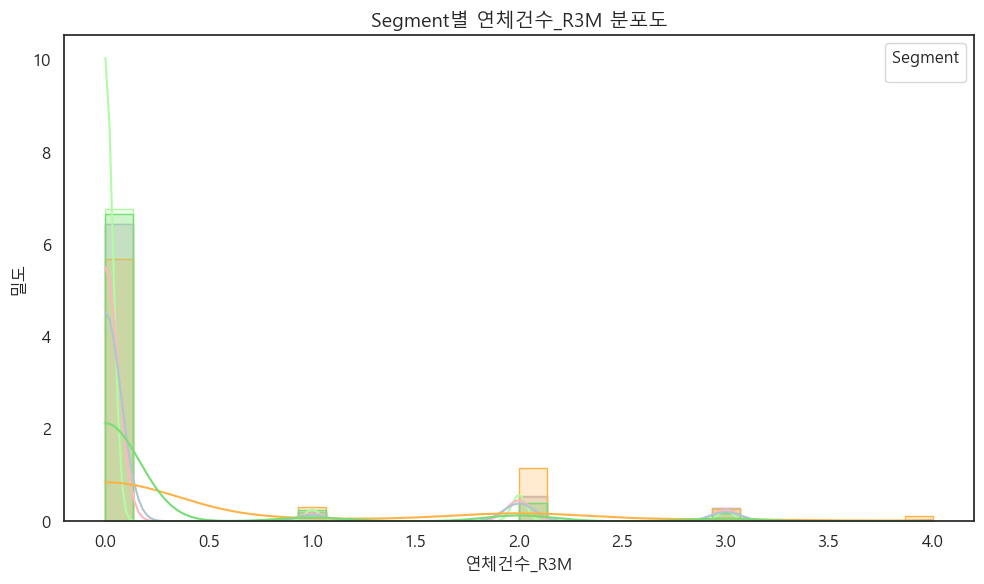

C:\Users\HR\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\HR\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(
C:\Users\HR\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\HR\AppData\Local\anaconda3\Lib\site-package

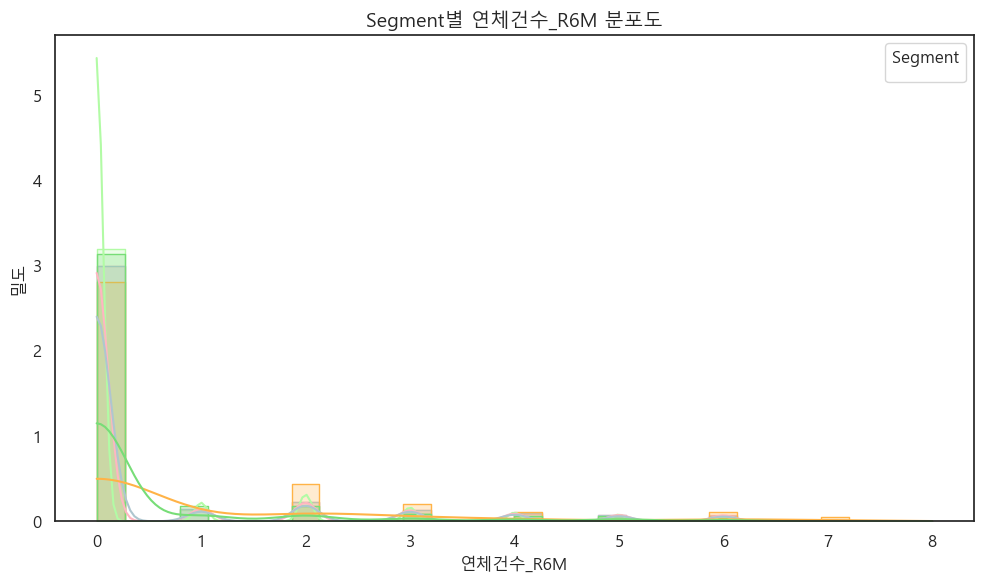

In [55]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ✅ 한글 폰트 설정
font_path = "C:/Windows/Fonts/malgun.ttf"
font_prop = fm.FontProperties(fname=font_path)

# ✅ 기준 월 리스트 및 경로 템플릿
months = ['201807', '201808', '201809', '201810', '201811', '201812']
member_path_tpl = "C:/Users/HR/Desktop/workspace/파이널프로젝트/open/train/1.회원정보/{ym}_train_회원정보.parquet"
perf_path_tpl = "C:/Users/HR/Desktop/workspace/파이널프로젝트/open/train/4.청구입금정보/{ym}_train_청구정보.parquet"

# ✅ 병합
member_list = []
perf_list = []

for ym in months:
    member_df = pd.read_parquet(member_path_tpl.format(ym=ym))[['ID', 'Segment']]
    perf_df = pd.read_parquet(perf_path_tpl.format(ym=ym))

    member_df['기준년월'] = ym
    perf_df['기준년월'] = ym

    member_list.append(member_df)
    perf_list.append(perf_df)

member_all = pd.concat(member_list, ignore_index=True)
perf_all = pd.concat(perf_list, ignore_index=True)

# ✅ 사용할 컬럼
target_cols = ['연체건수_R3M', '연체건수_R6M']
available_cols = [col for col in target_cols if col in perf_all.columns]
perf_selected = perf_all[['ID', '기준년월'] + available_cols]

merged = pd.merge(member_all, perf_selected, on=['ID', '기준년월'], how='inner')
merged['Segment'] = pd.Categorical(merged['Segment'], categories=['A', 'B', 'C', 'D', 'E'], ordered=True)

# ✅ 색상 설정
palette = {
    'A': '#77DD77',
    'B': '#FFB347',
    'C': '#AEC6CF',
    'D': '#FFB6C1',
    'E': '#B2FBA5',
}

# ✅ 분포 시각화
for col in available_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(
        data=merged,
        x=col,
        hue='Segment',
        palette=palette,
        kde=True,
        stat='density',
        common_norm=False,
        element='step',
        bins=30
    )
    plt.title(f"Segment별 {col} 분포도", fontproperties=font_prop, fontsize=14)
    plt.xlabel(col, fontproperties=font_prop)
    plt.ylabel("밀도", fontproperties=font_prop)
    plt.xticks(fontproperties=font_prop)
    plt.yticks(fontproperties=font_prop)
    plt.legend(title='Segment', prop=font_prop)
    plt.tight_layout()
    plt.show()

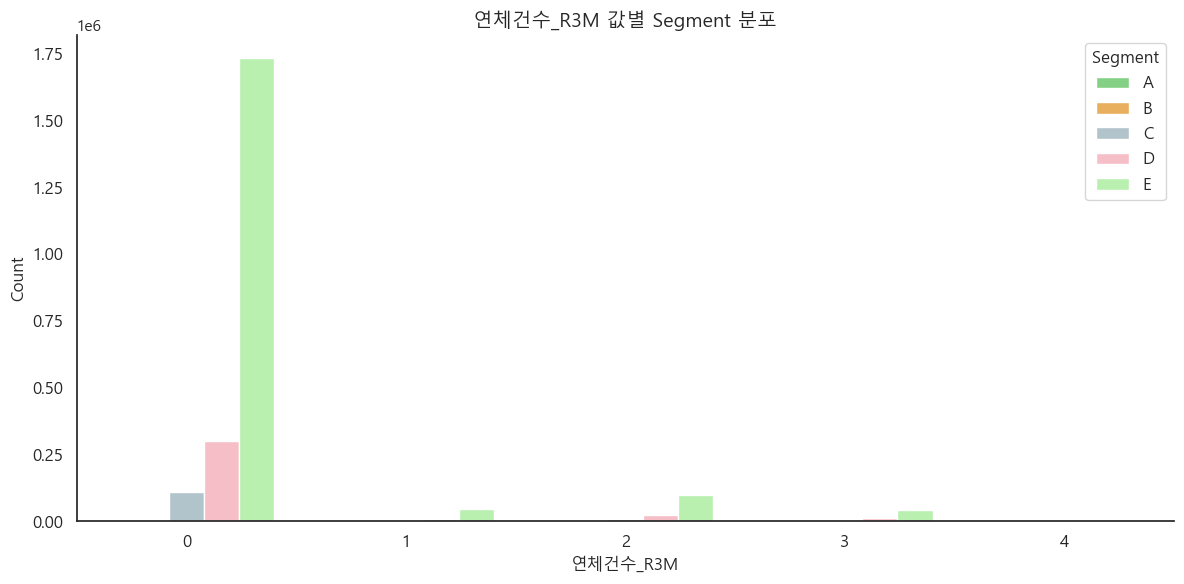

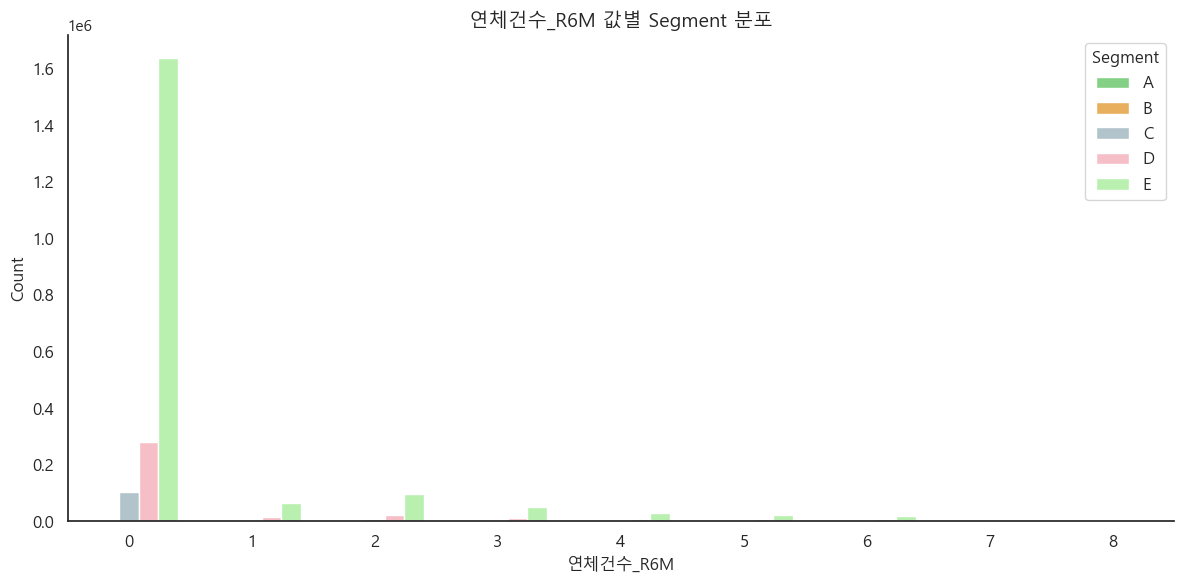

In [57]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ✅ 한글 폰트 설정
font_path = "C:/Windows/Fonts/malgun.ttf"
font_prop = fm.FontProperties(fname=font_path)

# ✅ 기준 월 리스트 및 파일 경로 템플릿
months = ['201807', '201808', '201809', '201810', '201811', '201812']
member_path_tpl = "C:/Users/HR/Desktop/workspace/파이널프로젝트/open/train/1.회원정보/{ym}_train_회원정보.parquet"
perf_path_tpl = "C:/Users/HR/Desktop/workspace/파이널프로젝트/open/train/4.청구입금정보/{ym}_train_청구정보.parquet"

# ✅ 데이터 불러오기
member_list = []
perf_list = []

for ym in months:
    member_df = pd.read_parquet(member_path_tpl.format(ym=ym))[['ID', 'Segment']]
    perf_df = pd.read_parquet(perf_path_tpl.format(ym=ym))

    member_df['기준년월'] = ym
    perf_df['기준년월'] = ym

    member_list.append(member_df)
    perf_list.append(perf_df)

# ✅ 데이터 병합
member_all = pd.concat(member_list, ignore_index=True)
perf_all = pd.concat(perf_list, ignore_index=True)

# ✅ 사용할 컬럼
target_cols = ['연체건수_R3M', '연체건수_R6M']
available_cols = [col for col in target_cols if col in perf_all.columns]
perf_selected = perf_all[['ID', '기준년월'] + available_cols]

merged = pd.merge(member_all, perf_selected, on=['ID', '기준년월'], how='inner')
merged['Segment'] = pd.Categorical(merged['Segment'], categories=['A', 'B', 'C', 'D', 'E'], ordered=True)

# ✅ 컬러 맵 정의 (순서 보장 위해 리스트 생성)
color_map = {
    'A': '#77DD77',
    'B': '#FFB347',
    'C': '#AEC6CF',
    'D': '#FFB6C1',
    'E': '#B2FBA5',
}
segment_order = ['A', 'B', 'C', 'D', 'E']
palette = [color_map[seg] for seg in segment_order]

# ✅ 시각화 - countplot (분포 보기용)
for col in available_cols:
    plt.figure(figsize=(12, 6))
    sns.countplot(
        data=merged,
        x=col,
        hue='Segment',
        order=sorted(merged[col].dropna().unique()),
        hue_order=segment_order,
        palette=palette
    )
    plt.title(f"{col} 값별 Segment 분포", fontproperties=font_prop, fontsize=14)
    plt.xlabel(col, fontproperties=font_prop)
    plt.ylabel("Count", fontproperties=font_prop)
    plt.xticks(fontproperties=font_prop)
    plt.yticks(fontproperties=font_prop)
    plt.legend(title='Segment', prop=font_prop)
    sns.despine()
    plt.tight_layout()
    plt.show()


C:\Users\HR\AppData\Local\Temp\ipykernel_13260\2231954377.py:40: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\HR\AppData\Local\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


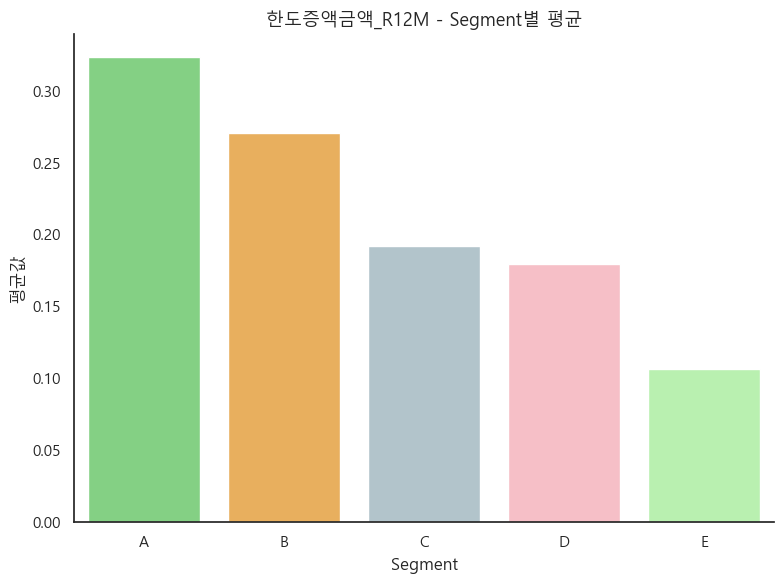

In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 🔹 기준 설정
months = ['201807', '201808', '201809', '201810', '201811', '201812']
member_path_tpl = "C:/Users/HR/Desktop/workspace/파이널프로젝트/open/train/1.회원정보/{ym}_train_회원정보.parquet"
perf_path_tpl = "C:/Users/HR/Desktop/workspace/파이널프로젝트/open/train/2.신용정보/{ym}_train_신용정보.parquet"

# 🔹 컬럼 지정
target_col = '한도증액금액_R12M'
color_map = {
    'A': '#77DD77',
    'B': '#FFB347',
    'C': '#AEC6CF',
    'D': '#FFB6C1',
    'E': '#B2FBA5',
}

# 🔹 데이터 불러오기
member_list = []
perf_list = []

for ym in months:
    member_df = pd.read_parquet(member_path_tpl.format(ym=ym), columns=['ID', 'Segment'])
    perf_df = pd.read_parquet(perf_path_tpl.format(ym=ym), columns=['ID', target_col])
    member_df['기준년월'] = ym
    perf_df['기준년월'] = ym
    member_list.append(member_df)
    perf_list.append(perf_df)

# 🔹 병합
member_all = pd.concat(member_list, ignore_index=True)
perf_all = pd.concat(perf_list, ignore_index=True)
df = pd.merge(member_all, perf_all, on=['ID', '기준년월'], how='inner')
df['Segment'] = pd.Categorical(df['Segment'], categories=['A', 'B', 'C', 'D', 'E'], ordered=True)

# 🔹 시각화
plt.figure(figsize=(8, 6))
sns.barplot(
    data=df,
    x='Segment',
    y=target_col,
    order=['A', 'B', 'C', 'D', 'E'],
    palette=color_map,
    ci=None
)
plt.title(f"{target_col} - Segment별 평균", fontsize=13)
plt.xlabel("Segment")
plt.ylabel("평균값")
sns.despine()
plt.tight_layout()
plt.show()


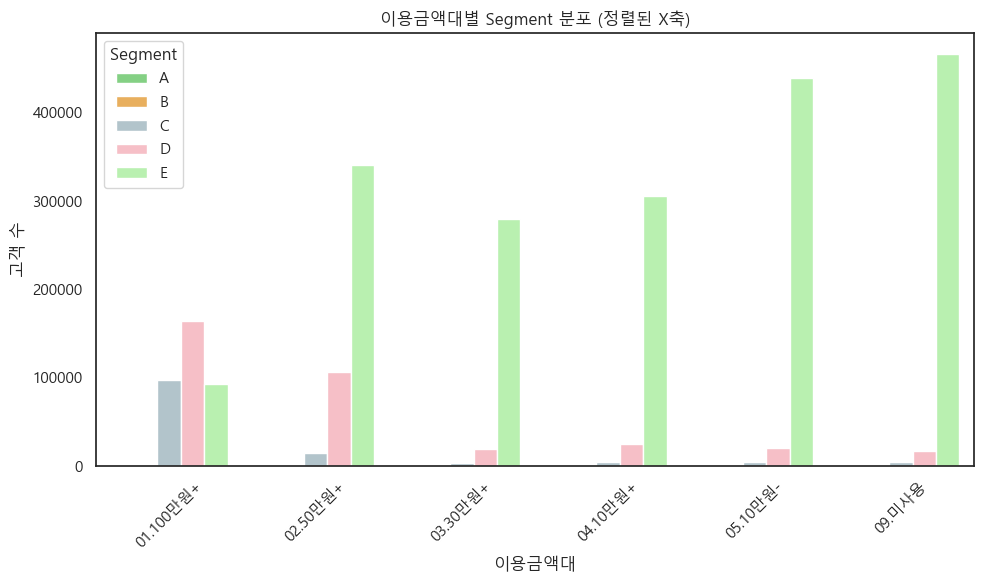

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ 경로 및 조건 설정
months = ['201807', '201808', '201809', '201810', '201811', '201812']
member_path_tpl = "C:/Users/HR/Desktop/workspace/파이널프로젝트/open/train/1.회원정보/{ym}_train_회원정보.parquet"
perf_path_tpl = "C:/Users/HR/Desktop/workspace/파이널프로젝트/open/train/3.승인매출정보/{ym}_train_승인매출정보.parquet"

color_map = {
    'A': '#77DD77',
    'B': '#FFB347',
    'C': '#AEC6CF',
    'D': '#FFB6C1',
    'E': '#B2FBA5',
}
segment_order = ['A', 'B', 'C', 'D', 'E']

# ✅ 데이터 불러오기
member_list, perf_list = [], []
for ym in months:
    member_df = pd.read_parquet(member_path_tpl.format(ym=ym))[['ID', 'Segment']]
    perf_df = pd.read_parquet(perf_path_tpl.format(ym=ym))[['ID', '이용금액대']]
    member_df['기준년월'] = ym
    perf_df['기준년월'] = ym
    member_list.append(member_df)
    perf_list.append(perf_df)

# ✅ 병합
member_all = pd.concat(member_list, ignore_index=True)
perf_all = pd.concat(perf_list, ignore_index=True)
merged = pd.merge(member_all, perf_all, on=['ID', '기준년월'], how='inner')

amount_order = sorted(merged['이용금액대'].dropna().unique())

# ✅ 시각화 (건수 기준)
plt.figure(figsize=(10, 6))
sns.countplot(
    data=merged,
    x='이용금액대',
    hue='Segment',
    order=amount_order,
    hue_order=segment_order,
    palette=color_map
)
plt.title("이용금액대별 Segment 분포 (정렬된 X축)")
plt.xlabel("이용금액대")
plt.ylabel("고객 수")
plt.legend(title="Segment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


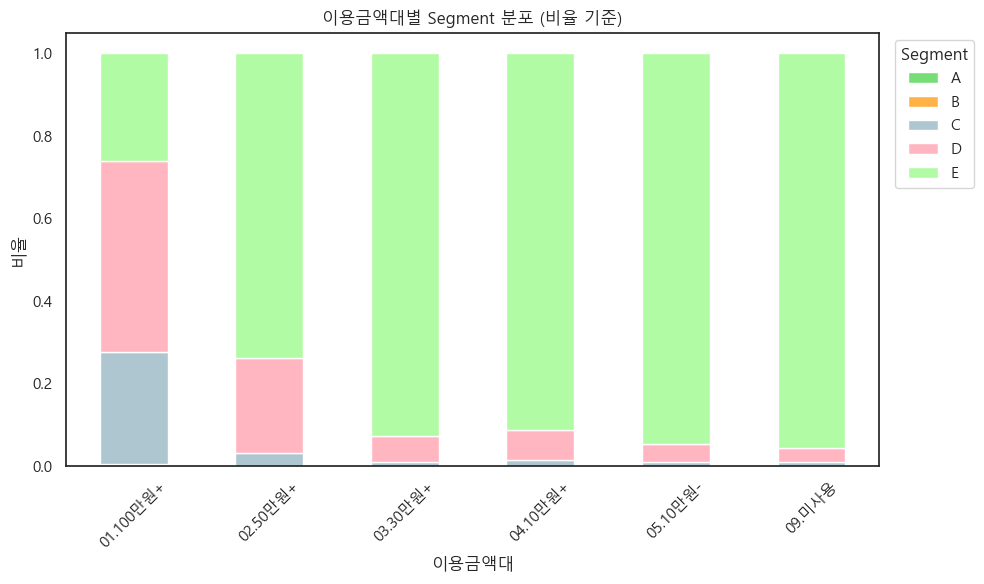

In [64]:
# ✅ groupby + pivot + 비율 계산
grouped = merged.groupby(['이용금액대', 'Segment']).size().reset_index(name='count')
pivot_df = grouped.pivot(index='이용금액대', columns='Segment', values='count').fillna(0)
pivot_df = pivot_df.loc[amount_order]
ratio_df = pivot_df.div(pivot_df.sum(axis=1), axis=0)

# ✅ 시각화 (비율 기준)
ratio_df.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=[color_map[s] for s in segment_order]
)
plt.title("이용금액대별 Segment 분포 (비율 기준)")
plt.xlabel("이용금액대")
plt.ylabel("비율")
plt.legend(title="Segment", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
